# FWC time series with SIC

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import time
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [3]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [4]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [5]:
# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

# open THETA zarr store - [degC]
theta_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options).THETA

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

In [6]:
# carve out beaufort region
salt_beaufort = salt_da.isel(i=slice(450,750),j=slice(110,390))
theta_beaufort = theta_da.isel(i=slice(450,750),j=slice(110,390))
ice_beaufort = ice_da.isel(i=slice(450,750),j=slice(110,390))

HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)
HH_land_beaufort = HH_grid_land.isel(i=slice(450,750),j=slice(110,390))

## 1. Select days after sea ice minimum each year and mask SIC>15%

In [7]:
ice_beaufort = ice_da.sel(time=slice('2014','2020')).isel(i=slice(450,750),j=slice(110,390))
beaufort_area = HH_grid.isel(i=slice(450,750),j=slice(110,390)).rAc

In [8]:
# calculating minimum based on extend (count grid cells where ice concentration >= 15% and sum their areas)

# salculate sea ice extent: sum the area of grid cells where SIC >= 15%
ice_extent = ((ice_beaufort >= 15) * beaufort_area).sum(dim=['i', 'j'])
ice_extent = ice_extent.where(ice_extent != 0)

# group by year
grouped = ice_extent.groupby("time.year")

# find the day of the minimum extent for each year
min_ice_dates = []
for year, data in grouped:
    sic_min_yr = data['time']
    min_day_tmp = sic_min_yr[data.argmin().values].values  # Get the time corresponding to min extent
    min_ice_dates.append(min_day_tmp)
    print(f"{year}: Minimum extent on {min_day_tmp}")

/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/dask/array/reductions.py:1113: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)


2014: Minimum extent on 2014-09-23T12:00:00.000000000


/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/dask/array/reductions.py:1113: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)


2015: Minimum extent on 2015-09-16T12:00:00.000000000
2016: Minimum extent on 2016-09-01T12:00:00.000000000
2017: Minimum extent on 2017-10-07T12:00:00.000000000
2018: Minimum extent on 2018-09-21T12:00:00.000000000
2019: Minimum extent on 2019-09-24T12:00:00.000000000
2020: Minimum extent on 2020-09-06T12:00:00.000000000


/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


In [9]:
# generate daily timestamps from each min date to Dec 31 of that year
date_arrays = [np.arange(np.datetime64(date), np.datetime64(f"{str(date)[:4]}-12-31") + np.timedelta64(1, 'D'), np.timedelta64(1, 'D'))
               for date in min_ice_dates]

# concatenate into one array
full_date_array = np.concatenate(date_arrays)

In [10]:
# select days after sea ice minimum for SIC and salinity

# select all timesteps after sea ice minimum each year
ice_yrs = ice_beaufort.sel(time=full_date_array)
# salt_yrs = salt_beaufort.sel(time=full_date_array).isel(k=slice(0,8)) # only upper 12 m
salt_yrs = salt_beaufort.sel(time=full_date_array).isel(k=slice(0,7)) # only upper 10 m

In [11]:
# look at depth of grid cell center and bottom of grid cell
print(salt_yrs.Z.values)
print(HH_grid.isel(k_u=slice(0,7)).Zu.values)

[-0.5   -1.57  -2.79  -4.185 -5.78  -7.595 -9.66 ]
[ -1.    -2.14  -3.44  -4.93  -6.63  -8.56 -10.76]


In [12]:
# list to store yearly masks
mask_list = []

for date in min_ice_dates:
    year = str(date.astype('datetime64[Y]'))  # Extract year as a string
    
    # select all days from the minimum ice date to Dec 31
    yearly_data = ice_yrs.sel(time=slice(str(date), f"{year}-12-31"))

    # get sea ice concentration on the minimum ice date
    sic_min_day = ice_yrs.sel(time=date)

    # create a mask for grid cells where sic >= 15% on the minimum ice date
    mask = sic_min_day >= 15  # 2D (i, j)

    # expand mask along time dimension to match yearly_data
    mask_expanded = mask.expand_dims(dim={"time": yearly_data.time}, axis=0)

    # store in list
    mask_list.append(mask_expanded)

# combine all yearly masks
sic_yrs_mask = xr.concat(mask_list, dim="time").combine_first(ice_yrs * 0)  # Align time with ice_yrs

# apply mask to sea ice ds
land_sic_mask_yr = (~sic_yrs_mask.astype(bool)) & (HH_grid.isel(i=slice(450,750),j=slice(110,390),k=0).mask_basin)
ice_yrs_masked = ice_yrs.where(land_sic_mask_yr)

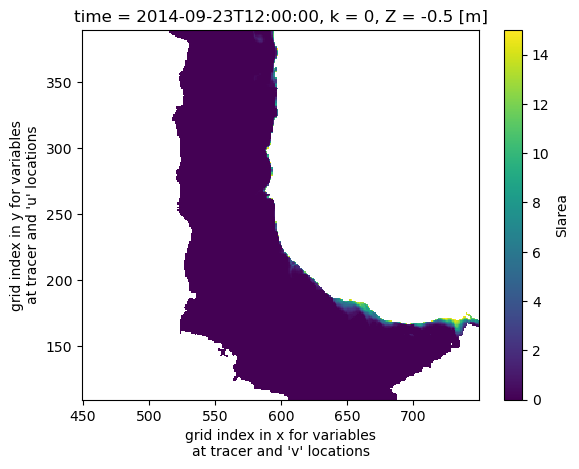

In [13]:
ice_yrs_masked.sel(time='2014').isel(time=0).plot();

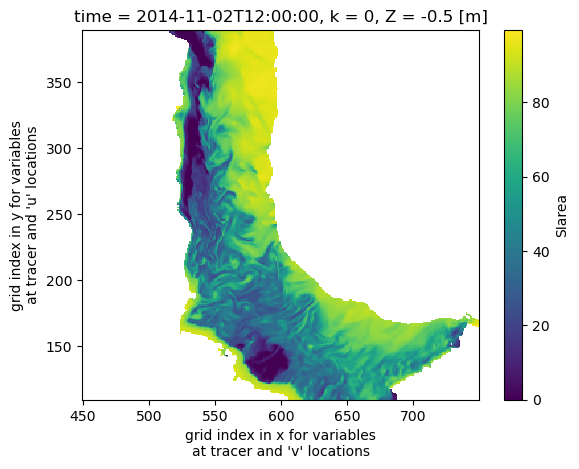

In [14]:
ice_yrs_masked.sel(time='2014').isel(time=40).plot();

## 2. Calculate FWC and bin data into 100 bins

In [15]:
def calculate_fwc(salt_da, salt_ref, dz):
    """
    Calculate the freshwater content (fwc)

    Parameters:
    salt_da (xr.DataArray): Salinity data array with a 'k' dimension.
    salt_ref (float): Reference salinity value.
    dz (xr.DataArray): Layer thickness data array with the same 'k' dimension.

    Returns:
    xr.DataArray: Freshwater content summed over the 'k' dimension.
    """
    fwc = ((salt_ref - salt_da) / salt_ref * dz).sum(dim='k')
    return fwc

In [16]:
# calculate FWC

# define reference salinity
salt_ref = 34.8

# dz = HH_grid.isel(i=slice(450,750),j=slice(110,390)).drF.isel(k=slice(0,8)) # upper 12
dz = HH_grid.isel(i=slice(450,750),j=slice(110,390)).drF.isel(k=slice(0,7)) # upper 10
fwc_beaufort_yrs = calculate_fwc(salt_yrs, salt_ref, dz)

In [17]:
# mask land grid cells and where SIC>15% on ice minimum date
# ice_yrs_masked = ice_yrs.where(land_sic_mask_yr)
fwc_yrs_masked = fwc_beaufort_yrs.where(land_sic_mask_yr)

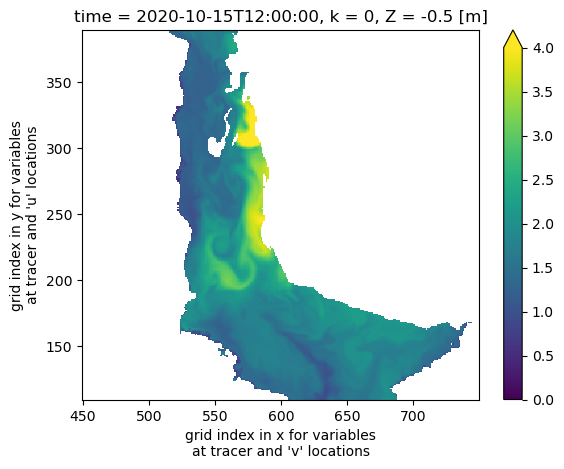

In [40]:
fwc_yrs_masked.sel(time='2020-10-15').plot(vmin=0,vmax=4);

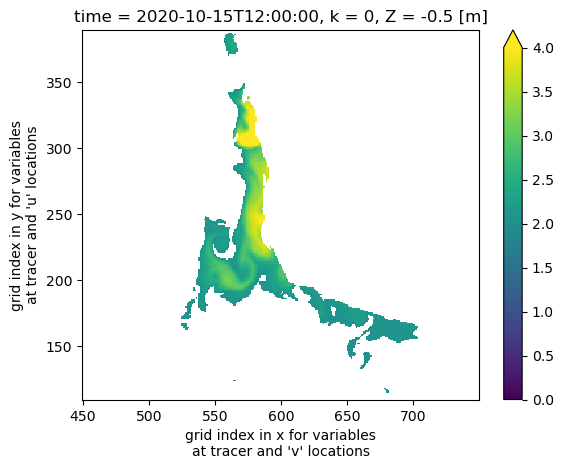

In [41]:
fwc_yrs_masked.sel(time='2020-10-15').where(fwc_yrs_masked.sel(time='2020-10-15')>2).plot(vmin=0,vmax=4);

In [49]:
fwc_over_2m = fwc_yrs_masked.where(fwc_yrs_masked>2)
fwc_under_2m = fwc_yrs_masked.where(fwc_yrs_masked<2)

In [18]:
# determine the upper end of the dataset
fwc_yrs_masked.max().values

array(6.75552669)

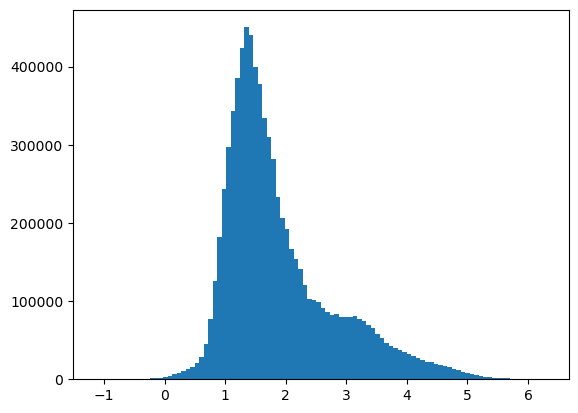

In [19]:
# look at histogram of FWC for a few years
plt.hist(np.ravel(fwc_yrs_masked.sel(time=slice('2014','2016')).values),100);

In [20]:
# define FWC bins
fwc_bins = np.linspace(0,5,99)
fwc_bins = np.append(fwc_bins, 7) # total of 100, the last bin is all FWC values between 5 and 7 m

In [21]:
len(fwc_bins)

100

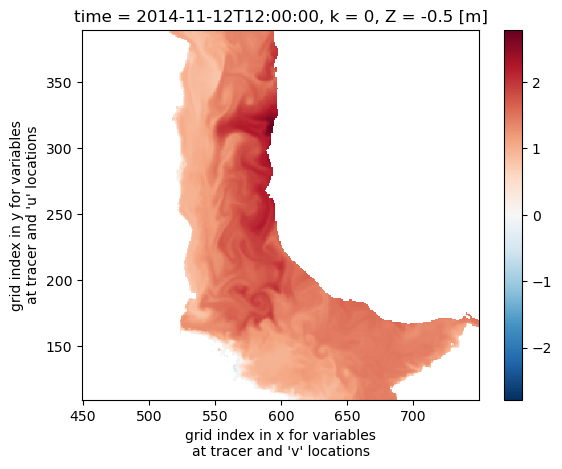

In [22]:
fwc_yrs_masked.isel(time=50).plot();

In [23]:
# bin each grid cell into FWC intervals
# use np.digitize to bin the values according to fwc_bins
fwc_binned_yrs = np.digitize(fwc_yrs_masked, fwc_bins, right=False)

In [24]:
fwc_binned_yrs.shape

(733, 280, 300)

In [25]:
# sanity check
print(fwc_binned_yrs[0,110,145]) # index = 75
print(fwc_bins[75]) # index provides the upper end of the bin interval
print(fwc_bins[74:76]) # upper and lower ends of the bin
print(fwc_yrs_masked.values[0,110,145]) # actual value from this grid cell, and it falls within the bin range - looks good!

75
3.826530612244898
[3.7755102  3.82653061]
3.824052925438716


In [26]:
fwc_binned_da = xr.DataArray(data = fwc_binned_yrs, dims=['time', 'j', 'i'],\
                             coords={'time': fwc_yrs_masked.time.values, 'j': fwc_yrs_masked.j.values, 'i': fwc_yrs_masked.i.values})

In [27]:
# mask out land and sea ice
fwc_binned_da = fwc_binned_da.where(land_sic_mask_yr)

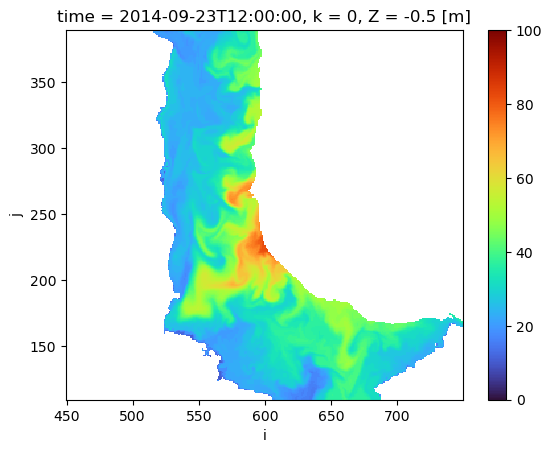

In [28]:
fwc_binned_da.isel(time=0).plot(vmin=0,vmax=100,cmap='turbo');

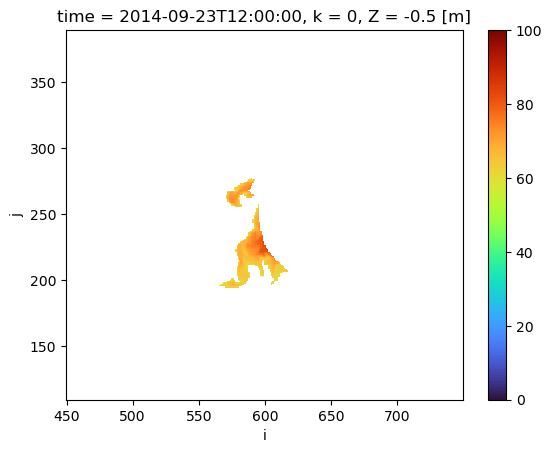

In [29]:
fwc_binned_da.isel(time=0).where((fwc_binned_da.isel(time=0)>60) & (fwc_binned_da.isel(time=0)<90)).plot(vmin=0,vmax=100,cmap='turbo');

In [30]:
ice_yrs_masked.shape

(733, 280, 300)

In [31]:
fwc_binned_da.shape

(733, 280, 300)

## 3a. Group FWC>2 and calculate mean SIC for time series

In [53]:
# select all cells with FWC>2
ice_fwc_over_2m = ice_yrs_masked.where(fwc_yrs_masked>2)
ice_fwc_under_2m = ice_yrs_masked.where(fwc_yrs_masked<2)

In [59]:
ice_fwc_over_2m_avg = ice_fwc_over_2m.mean(dim=['i','j'])
ice_fwc_under_2m_avg = ice_fwc_under_2m.mean(dim=['i','j'])

ice_fwc_over_2m_avg = ice_fwc_over_2m.std(dim=['i','j'])
ice_fwc_under_2m_avg = ice_fwc_under_2m.std(dim=['i','j'])

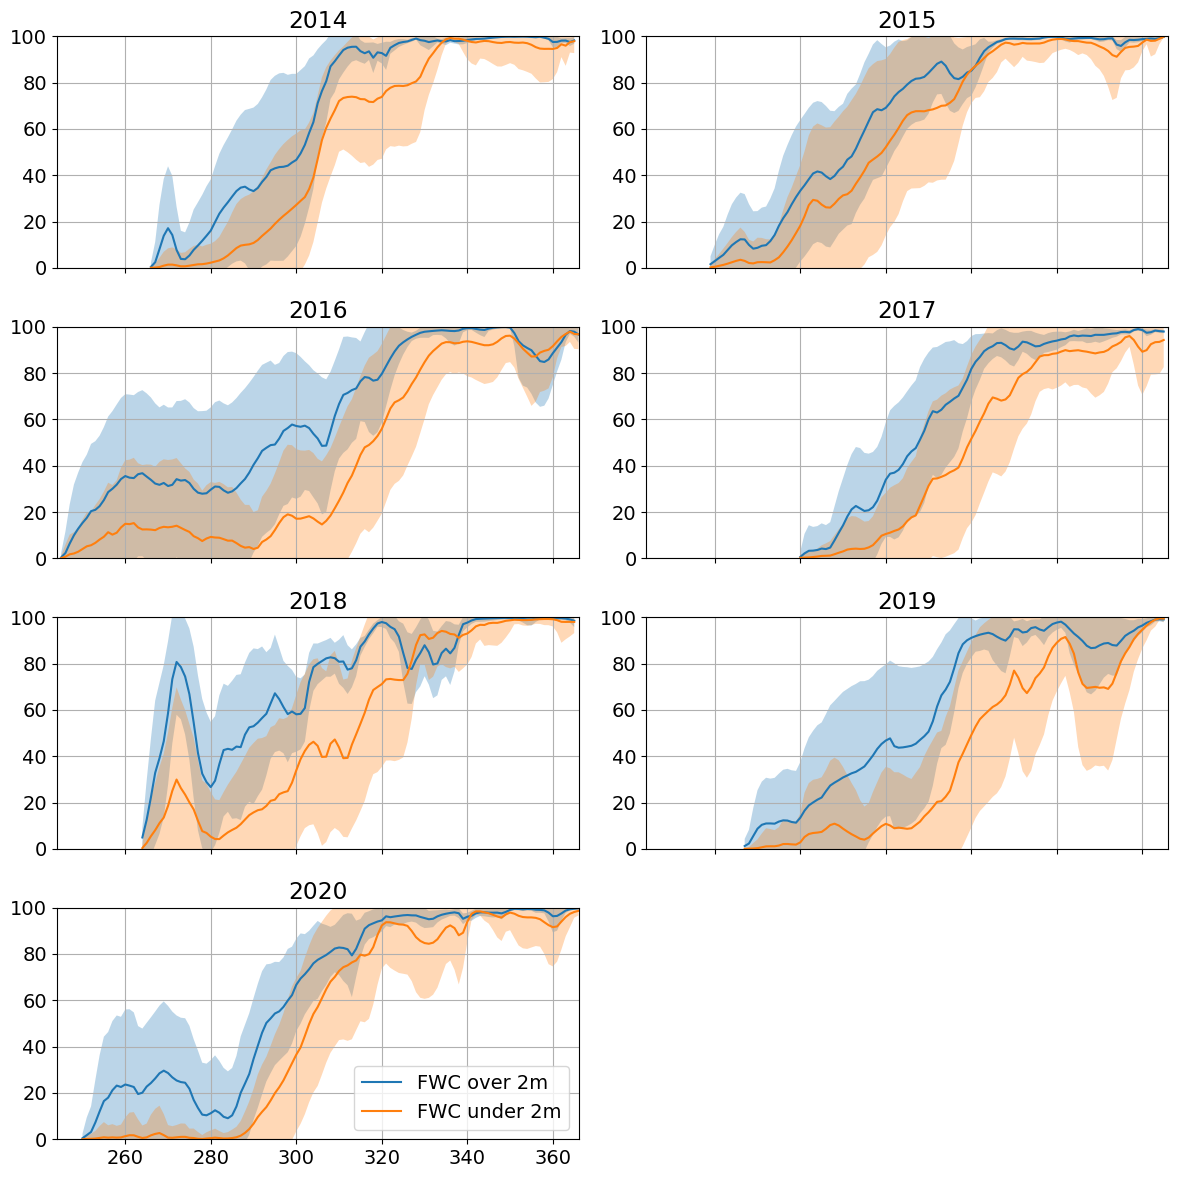

In [69]:
years = np.arange(2014, 2021)
nrows = int(np.ceil(len(years) / 2))

fig, axes = plt.subplots(nrows, 2, figsize=[12, 12], sharex=True)
plt.rcParams['font.size'] = 14
axes = axes.flatten()

# Compute mean and std over all time
full_mean_over = ice_fwc_over_2m.mean(dim=['i', 'j'])
full_std_over = ice_fwc_over_2m.std(dim=['i', 'j'])

full_mean_under = ice_fwc_under_2m.mean(dim=['i', 'j'])
full_std_under = ice_fwc_under_2m.std(dim=['i', 'j'])

for i, year in enumerate(years):
    ax = axes[i]

    # Select data for the given year
    data_over = ice_fwc_over_2m.sel(time=str(year))
    data_under = ice_fwc_under_2m.sel(time=str(year))

    # Get time as day-of-year
    doy = data_over['time'].dt.dayofyear

    # Mean over i,j for this year's time series
    mean_over = data_over.mean(dim=['i','j'])
    mean_under = data_under.mean(dim=['i','j'])

    # Use full std for shading
    std_over = full_std_over.sel(time=mean_over['time'])
    std_under = full_std_under.sel(time=mean_under['time'])

    # Plot mean with global std shading
    ax.plot(doy, mean_over, label='FWC over 2m')
    ax.fill_between(doy, mean_over - std_over, mean_over + std_over, alpha=0.3)

    ax.plot(doy, mean_under, label='FWC under 2m')
    ax.fill_between(doy, mean_under - std_under, mean_under + std_under, alpha=0.3)

    ax.set_title(f"{year}")
    ax.set_xlim([244, 366])
    ax.set_ylim([0,100])
    ax.grid(True)

# Turn off the last axis if unused (8th subplot)
if len(years) < len(axes):
    axes[-1].axis('off')

# Add legend to the last used axis
axes[len(years) - 1].legend(loc='lower right')

plt.tight_layout()
plt.show()